In [28]:
import os 
import requests
import pypdb 
# check membrane proteins 
def emdb_to_pdb(emdb_id):
    import requests    
    url = f"https://www.ebi.ac.uk/emdb/api/entry/{emdb_id}"
    response = requests.get(url)
    data = response.json()
    try:
        pdb_id = data["crossreferences"]["pdb_list"]["pdb_reference"][0]["pdb_id"]
 
        return pdb_id    
    except (KeyError, IndexError):
        return None

def membrane_present(emdb):
    pdb_id = emdb_to_pdb(emdb)
    membrane_pdb_dir = "/home/abharadwaj1/dev/students/lotte/membranedata/pdb"
    if pdb_id is None:
        print(f"No PDB ID found for EMDB ID: {emdb}. Check manually")
        return None
    pdb_file_path = os.path.join(membrane_pdb_dir, f"{pdb_id}.pdb")
    if os.path.exists(pdb_file_path):
        return True
    else:
        return False
    
    

    
def get_biological_class(emdb_id):
    pdb = emdb_to_pdb(emdb_id)
    try:
        pypdb_desc = pypdb.describe_pdb(pdb_id=pdb)
        protein_count = pypdb_desc['rcsb_entry_info']['polymer_entity_count_protein']  
        rna_count = pypdb_desc['rcsb_entry_info']['polymer_entity_count_rna']      
        dna_count = pypdb_desc['rcsb_entry_info']['polymer_entity_count_dna']      
        nucleic_acid_count = pypdb_desc['rcsb_entry_info']['polymer_entity_count_nucleic_acid']  
    except Exception as e:
        print(f"Error retrieving data for PDB ID: {pdb}. Error: {e}")
        return None

    if protein_count > 0 and rna_count == 0 and dna_count == 0:
        return "Protein"
    elif rna_count > 0 and dna_count == 0:
        return "RNA"
    elif dna_count > 0 and rna_count == 0:
        return "DNA"
    elif dna_count > 0 and rna_count > 0:
        return "Nucleic Acid"
    else:
        return "Other"


    # url = f"https://www.ebi.ac.uk/emdb/api/entry/{emdb_id}"
    # response = requests.get(url)
    # if response.status_code == 200:
    #     data = response.json()
    #     try:
    #         instance = data["sample"]["macromolecule_list"]["macromolecule"][0]["instance_type"]
    #         return instance
    #     except (KeyError, IndexError):
    #         print(f"Biological class not found for EMDB ID: {emdb_id}")
    #         return None
    # else:
    #     print(f"Failed to retrieve data for EMDB ID: {emdb_id}")
    #     return None

In [24]:
import pypdb 

pdbid = "6gml"
desc = pypdb.describe_pdb(pdbid)
print(desc)

{'audit_author': [{'identifier_orcid': '0000-0003-1985-2994', 'name': 'Vos, S.M.', 'pdbx_ordinal': 1}, {'identifier_orcid': '0000-0002-8200-2493', 'name': 'Farnung, L.', 'pdbx_ordinal': 2}, {'identifier_orcid': '0000-0003-1837-5233', 'name': 'Urlaub, H.', 'pdbx_ordinal': 3}, {'identifier_orcid': '0000-0001-5454-7755', 'name': 'Cramer, P.', 'pdbx_ordinal': 4}], 'citation': [{'country': 'UK', 'id': 'primary', 'journal_abbrev': 'Nature', 'journal_id_astm': 'NATUAS', 'journal_id_csd': '0006', 'journal_id_issn': '1476-4687', 'journal_volume': '560', 'page_first': '601', 'page_last': '606', 'pdbx_database_id_doi': '10.1038/s41586-018-0442-2', 'pdbx_database_id_pub_med': 30135580, 'rcsb_authors': ['Vos, S.M.', 'Farnung, L.', 'Urlaub, H.', 'Cramer, P.'], 'rcsb_is_primary': 'Y', 'rcsb_journal_abbrev': 'Nature', 'title': 'Structure of paused transcription complex Pol II-DSIF-NELF.', 'year': 2018}], 'database2': [{'database_code': '6GML', 'database_id': 'PDB', 'pdbx_doi': '10.2210/pdb6gml/pdb', '

In [ ]:
emdb_ids_locscale

In [14]:
import json 
emdb_ids_locscale_json = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/emdb_ids_locscale.json"

with open(emdb_ids_locscale_json, 'r') as f:
    emdb_ids_locscale = json.load(f)

print(emdb_ids_locscale.keys())
#dict_keys(['training', 'validation', 'testing_and_uncertainty_calibration', 'additional_test'])
training_emdb_ids = emdb_ids_locscale['training']
validation_emdb_ids = emdb_ids_locscale['validation']
testing = emdb_ids_locscale['testing_and_uncertainty_calibration']
additional_test_emdb_ids = emdb_ids_locscale['additional_test']

dict_keys(['training', 'validation', 'testing_and_uncertainty_calibration', 'additional_test'])


In [29]:
biological_classes_training = [get_biological_class(emdb_id) for emdb_id in training_emdb_ids]
biological_classes_validation = [get_biological_class(emdb_id) for emdb_id in validation_emdb_ids]
biological_classes_testing = [get_biological_class(emdb_id) for emdb_id in testing]
biological_classes_additional_test = [get_biological_class(emdb_id) for emdb_id in additional_test_emdb_ids]
print("Biological classes in training set:", set(biological_classes_training))
print("Biological classes in validation set:", set(biological_classes_validation))
print("Biological classes in testing set:", set(biological_classes_testing))
print("Biological classes in additional test set:", set(biological_classes_additional_test))

Error retrieving data for PDB ID: None. Error: 'NoneType' object has no attribute 'replace'


/home/abharadwaj1/miniconda3/envs/locscale2/lib/python3.11/site-packages/pypdb/util/http_requests.py:61: UserWarning: Too many failures on requests. Exiting...
  warnings.warn("Too many failures on requests. Exiting...")


Error retrieving data for PDB ID: 6i2x. Error: 'NoneType' object has no attribute 'status_code'
Error retrieving data for PDB ID: None. Error: 'NoneType' object has no attribute 'replace'
Biological classes in training set: {'DNA', 'RNA', None, 'Nucleic Acid', 'Protein'}
Biological classes in validation set: {'Protein', 'DNA'}
Biological classes in testing set: {'Protein', 'RNA'}
Biological classes in additional test set: {'Protein', None, 'RNA'}


In [30]:
# percentage of each biological class in each set
from collections import Counter
def calculate_percentage(biological_classes):
    total = len(biological_classes)
    counter = Counter(biological_classes)
    percentages = {cls: (count / total) * 100 for cls, count in counter.items()}
    return percentages

training_list_no_none = [cls for cls in biological_classes_training if cls is not None]
validation_list_no_none = [cls for cls in biological_classes_validation if cls is not None]
testing_list_no_none = [cls for cls in biological_classes_testing if cls is not None]
additional_test_list_no_none = [cls for cls in biological_classes_additional_test if cls is not None]

training_percentages = calculate_percentage(training_list_no_none)
validation_percentages = calculate_percentage(validation_list_no_none)
testing_percentages = calculate_percentage(testing_list_no_none)
additional_test_percentages = calculate_percentage(additional_test_list_no_none)

print("Percentage of each biological class in training set:", training_percentages)
print("Percentage of each biological class in validation set:", validation_percentages)
print("Percentage of each biological class in testing set:", testing_percentages)
print("Percentage of each biological class in additional test set:", additional_test_percentages)


Percentage of each biological class in training set: {'Protein': 80.45977011494253, 'Nucleic Acid': 5.747126436781609, 'RNA': 11.494252873563218, 'DNA': 2.2988505747126435}
Percentage of each biological class in validation set: {'Protein': 92.85714285714286, 'DNA': 7.142857142857142}
Percentage of each biological class in testing set: {'Protein': 90.9090909090909, 'RNA': 9.090909090909092}
Percentage of each biological class in additional test set: {'Protein': 91.30434782608695, 'RNA': 8.695652173913043}


In [31]:
percentage_overall = calculate_percentage(training_list_no_none + validation_list_no_none + testing_list_no_none + additional_test_list_no_none)
print("Overall percentage of each biological class:", percentage_overall)

Overall percentage of each biological class: {'Protein': 84.44444444444444, 'Nucleic Acid': 3.7037037037037033, 'RNA': 9.62962962962963, 'DNA': 2.2222222222222223}


In [21]:
all_emdb_ids = training_emdb_ids + validation_emdb_ids + testing + additional_test_emdb_ids
membrane_presence = {emdb_id: membrane_present(emdb_id) for emdb_id in all_emdb_ids}

print("Membrane presence for each EMDB ID:", membrane_presence)

No PDB ID found for EMDB ID: 0589. Check manually
No PDB ID found for EMDB ID: 15949. Check manually
Membrane presence for each EMDB ID: {'0026': False, '0038': False, '0071': False, '0093': True, '0094': True, '0132': False, '0408': False, '0415': True, '0452': False, '0490': False, '0492': False, '0589': None, '0592': False, '0776': False, '10049': True, '10069': False, '10100': False, '10106': False, '10273': False, '10279': True, '10324': False, '10418': True, '10534': False, '10585': False, '10595': False, '10617': False, '20145': True, '20146': True, '20189': False, '20234': False, '20249': False, '20254': False, '20259': False, '20270': False, '20271': False, '20521': False, '20986': True, '21012': False, '21107': False, '21144': False, '21391': False, '3661': False, '3662': False, '3802': False, '3885': True, '3908': False, '4032': True, '4073': False, '4074': False, '4079': False, '4148': False, '4162': False, '4192': False, '4214': False, '4241': False, '4272': True, '4288': 

In [34]:
# dump to csv with columns emdb_id, biological_class, membrane_presence, notes (mention automatic or manual check)
import pandas as pd
data = []
for emdb_id in all_emdb_ids:
    biological_class = get_biological_class(emdb_id)
    membrane = membrane_presence[emdb_id]
    if membrane is None or biological_class is None:
        note = "Manual check needed"
    else:
        note = "Automatic check"
    dataset = "training" if emdb_id in training_emdb_ids \
        else "validation" if emdb_id in validation_emdb_ids \
        else "testing" if emdb_id in testing \
        else "additional_test"

    data.append({"emdb_id": emdb_id, "biological_class": biological_class, "membrane_presence": membrane, "notes": note, "dataset": dataset})

df = pd.DataFrame(data)
output_csv_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/emdb_biological_class_and_membrane_presence.csv"
df.to_csv(output_csv_path, index=False)
print(f"Data saved to {output_csv_path}")


Error retrieving data for PDB ID: None. Error: 'NoneType' object has no attribute 'replace'
Error retrieving data for PDB ID: 6i2x. Error: 'NoneType' object has no attribute 'status_code'
Error retrieving data for PDB ID: None. Error: 'NoneType' object has no attribute 'replace'
Data saved to /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/emdb_biological_class_and_membrane_presence.csv


In [23]:
percentage_membrane_found = sum(1 for presence in membrane_presence.values() if presence) / len(membrane_presence) * 100
percentage_membrane_absent = sum(1 for presence in membrane_presence.values() if presence == False) / len(membrane_presence) * 100
print(f"Percentage of EMDB entries with membrane found: {percentage_membrane_found:.2f}%")
print(f"Percentage of EMDB entries with membrane absent: {percentage_membrane_absent:.2f}%")


Percentage of EMDB entries with membrane found: 33.82%
Percentage of EMDB entries with membrane absent: 64.71%


Text(0.5, 1.0, 'Biological Classes in Overall Dataset')

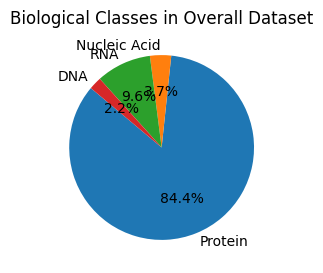

In [35]:
# make a pie chart of the biological classes in the overall dataset and a pie chart of the membrane presence in the overall dataset
import matplotlib.pyplot as plt
# Pie chart for biological classes
labels = list(percentage_overall.keys())
sizes = list(percentage_overall.values())
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Biological Classes in Overall Dataset")


Text(0.5, 1.0, 'Membrane Presence in Overall Dataset')

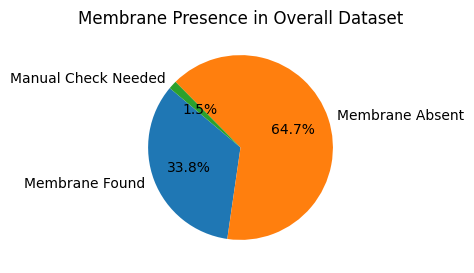

In [36]:
# Pie chart for membrane presence
membrane_labels = ["Membrane Found", "Membrane Absent", "Manual Check Needed"]
membrane_sizes = [sum(1 for presence in membrane_presence.values() if presence), 
                  sum(1 for presence in membrane_presence.values() if presence == False)]
membrane_sizes.append(sum(1 for presence in membrane_presence.values() if presence is None))
plt.figure(figsize=(3, 3))
plt.pie(membrane_sizes, labels=membrane_labels, autopct='%1.1f%%', startangle=140)
plt.title("Membrane Presence in Overall Dataset")




In [37]:
# percentage of membrane presence in each dataset
membrane_presence_training = {emdb_id: membrane_presence[emdb_id] for emdb_id in training_emdb_ids}
membrane_presence_validation = {emdb_id: membrane_presence[emdb_id] for emdb_id in validation_emdb_ids}
membrane_presence_testing = {emdb_id: membrane_presence[emdb_id] for emdb_id in testing}
membrane_presence_additional_test = {emdb_id: membrane_presence[emdb_id] for emdb_id in additional_test_emdb_ids}
def calculate_membrane_percentage(membrane_presence_dict):
    total = len(membrane_presence_dict)
    membrane_found = sum(1 for presence in membrane_presence_dict.values() if presence)
    membrane_absent = sum(1 for presence in membrane_presence_dict.values() if presence == False)
    manual_check_needed = sum(1 for presence in membrane_presence_dict.values() if presence is None)
    
    return {
        "Membrane Found": (membrane_found / total) * 100,
        "Membrane Absent": (membrane_absent / total) * 100,
        "Manual Check Needed": (manual_check_needed / total) * 100
    }
membrane_percentage_training = calculate_membrane_percentage(membrane_presence_training)
membrane_percentage_validation = calculate_membrane_percentage(membrane_presence_validation)
membrane_percentage_testing = calculate_membrane_percentage(membrane_presence_testing)
membrane_percentage_additional_test = calculate_membrane_percentage(membrane_presence_additional_test)
print("Membrane presence percentage in training set:", membrane_percentage_training)
print("Membrane presence percentage in validation set:", membrane_percentage_validation)
print("Membrane presence percentage in testing set:", membrane_percentage_testing)
print("Membrane presence percentage in additional test set:", membrane_percentage_additional_test)


Membrane presence percentage in training set: {'Membrane Found': 29.213483146067414, 'Membrane Absent': 69.66292134831461, 'Manual Check Needed': 1.1235955056179776}
Membrane presence percentage in validation set: {'Membrane Found': 64.28571428571429, 'Membrane Absent': 35.714285714285715, 'Manual Check Needed': 0.0}
Membrane presence percentage in testing set: {'Membrane Found': 45.45454545454545, 'Membrane Absent': 54.54545454545454, 'Manual Check Needed': 0.0}
Membrane presence percentage in additional test set: {'Membrane Found': 26.08695652173913, 'Membrane Absent': 69.56521739130434, 'Manual Check Needed': 4.3478260869565215}


In [ ]:
total